# PR-2: Robust House-Price Regression Pipeline
**Regularization · Cross-Validation · Linear vs Non-Linear Regressors**

**Problem:** the company's basic regression model overfits and gives unstable predictions across datasets. This notebook builds a robust pipeline that applies regularization, uses proper cross-validation, compares linear and non-linear regressors, and selects the best model on validation performance.

**Dataset:** 3,800 property sales (2010-2023), 10 usable predictors, target = `house_price_inr`.

| Part | Content |
|---|---|
| A | Conceptual foundation (theory) |
| B | Dataset understanding & preparation |
| C | Ridge & Lasso |
| D | Cross-validation strategies |
| E | Decision Tree & Random Forest |
| F | Support Vector Regression |
| G | Model comparison & evaluation |
| H | Final report |

## Part B: Dataset Understanding & Preparation
**Task 6: Features and target.** The target is `house_price_inr`. Predictors: property size and structure (`area_sqft`, `bedrooms`, `bathrooms`), location indicators (`location_score`, `distance_city_km`, `near_school`, `near_metro`, `crime_rate_index`), age (`property_age`) and the time of sale (`sale_date`, converted to `sale_year`). `property_id` is only an identifier and is dropped.

In [7]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import (cross_val_predict, train_test_split, KFold, StratifiedKFold, LeaveOneOut,
                                     TimeSeriesSplit, GridSearchCV, cross_validate, cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
pd.options.display.float_format = "{:,.4f}".format



In [8]:
df = pd.read_csv("house_prices.csv", parse_dates=["sale_date"])
print("Shape:", df.shape)
print("Missing values:", int(df.isna().sum().sum()), "| Duplicate property_ids:", int(df.property_id.duplicated().sum()))
df.head()

Shape: (3800, 12)
Missing values: 0 | Duplicate property_ids: 0


,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1000,21,3.8000,0,0,4.8400,35154898
1,200002,2019-12-01,2383,5,4,5.3000,28,10.9000,1,1,2.8900,26710893
2,200003,2016-10-01,1047,3,3,5.9000,7,27.5000,0,1,4.0400,11216242
3,200004,2013-03-01,1753,4,3,7.0000,27,12.1000,0,0,3.2800,21984310
4,200005,2013-07-01,1728,4,4,10.0000,32,1.4000,0,1,3.8400,25080429


In [9]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
property_id,"3,800.0000","201,900.5000","200,001.0000","200,950.7500","201,900.5000","202,850.2500","203,800.0000","1,097.1098"
sale_date,3800,2016-11-27 23:45:13.263158016,2010-01-01 00:00:00,2013-06-01 00:00:00,2016-12-01 00:00:00,2020-05-01 00:00:00,2023-12-01 00:00:00,NaN
area_sqft,"3,800.0000","1,716.9255",500.0000,"1,322.0000","1,700.5000","2,105.0000","3,776.0000",582.9966
bedrooms,"3,800.0000",3.4282,1.0000,2.0000,3.0000,4.0000,7.0000,1.3567
bathrooms,"3,800.0000",2.9163,1.0000,2.0000,3.0000,4.0000,6.0000,1.1335
location_score,"3,800.0000",6.5022,1.0000,5.3000,6.5000,7.7000,10.0000,1.7669
property_age,"3,800.0000",22.5371,1.0000,14.0000,20.0000,29.0000,80.0000,12.3257
distance_city_km,"3,800.0000",13.0851,1.0000,8.5000,13.0000,17.5000,38.7000,6.5374
near_school,"3,800.0000",0.5484,0.0000,0.0000,1.0000,1.0000,1.0000,0.4977
near_metro,"3,800.0000",0.4729,0.0000,0.0000,0.0000,1.0000,1.0000,0.4993


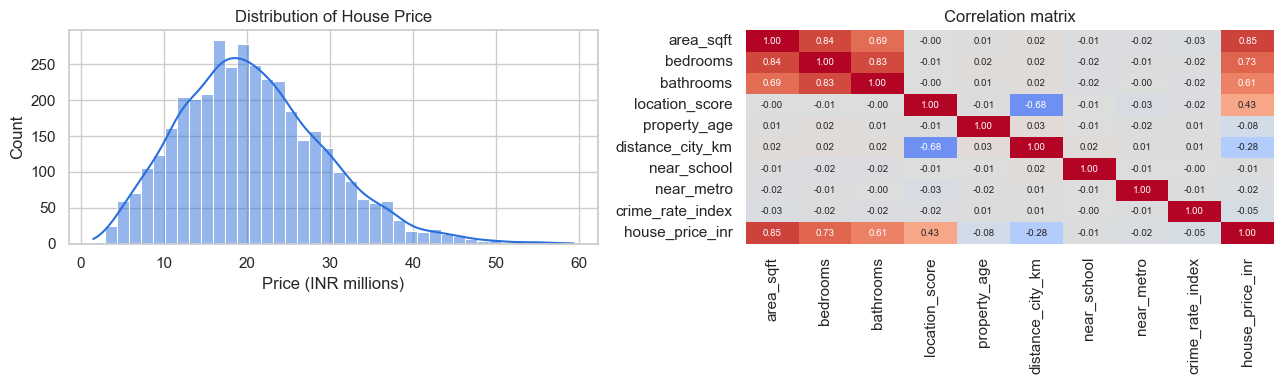

area_sqft           0.8500
bedrooms            0.7260
bathrooms           0.6100
location_score      0.4290
near_school        -0.0120
near_metro         -0.0250
crime_rate_index   -0.0520
property_age       -0.0790
distance_city_km   -0.2810
Name: house_price_inr, dtype: float64


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df.house_price_inr / 1e6, bins=40, kde=True, ax=ax[0], color="#2a6fdb")
ax[0].set(title="Distribution of House Price", xlabel="Price (INR millions)")
corr = df.drop(columns=["property_id", "sale_date"]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[1], annot_kws={"size": 7}, cbar=False)
ax[1].set_title("Correlation matrix")
plt.tight_layout(); plt.show()
print(corr["house_price_inr"].drop("house_price_inr").sort_values(ascending=False).round(3))

**Interpretation.** Price is right-skewed with a long upper tail. `area_sqft` is by far the strongest driver (r = 0.85), followed by `bedrooms`, `bathrooms` and `location_score`; `distance_city_km` and `property_age` are negative. `bedrooms`/`bathrooms` are correlated with area, so multicollinearity is expected. This is exactly the situation where regularization is useful.

In [11]:
# Feature engineering: sale_date -> sale_year (numeric, time-related). property_id is an identifier (no signal) -> dropped.
df["sale_year"] = df.sale_date.dt.year
TARGET = "house_price_inr"
FEATURES = ["area_sqft", "bedrooms", "bathrooms", "location_score", "property_age",
            "distance_city_km", "near_school", "near_metro", "crime_rate_index", "sale_year"]
X, y = df[FEATURES], df[TARGET]
print("Features:", FEATURES); print("Target  :", TARGET)

Features: ['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index', 'sale_year']
Target  : house_price_inr


**Task 7: Train-test split.** 80 / 20 random split with a fixed seed. The 20 % test set is used **once**, at the end. All hyper-parameter tuning uses cross-validation on the training set.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape}   Test: {X_test.shape}")
# The test set is locked away: ALL tuning / model selection below uses cross-validation on the training set only.

Train: (3040, 10)   Test: (760, 10)


**Task 8: Preprocessing.** No missing values or duplicates were found. Features are standardised with `StandardScaler` **inside a `Pipeline`**, so the scaler is fitted on the training folds only (no leakage). Scaling is required for Ridge, Lasso and SVR and not needed for trees.

In [13]:
# Scaling is done INSIDE a Pipeline so that, during cross-validation, the scaler is fit only on the training folds
# (this prevents data leakage). Tree-based models do not need scaling, so they get no scaler.
def scaled(model):
    return Pipeline([("scale", StandardScaler()), ("model", model)])

print(pd.DataFrame({"mean": X_train.mean(), "std": X_train.std()}).round(2))

                       mean      std
area_sqft        1,721.1500 584.3600
bedrooms             3.4400   1.3600
bathrooms            2.9200   1.1400
location_score       6.5100   1.7400
property_age        22.5500  12.3400
distance_city_km    13.1000   6.5500
near_school          0.5500   0.5000
near_metro           0.4700   0.5000
crime_rate_index     4.2400   2.0500
sale_year        2,016.4500   4.0200


In [14]:
def evaluate(model, name):
    """Fit on train, return train/test metrics."""
    model.fit(X_train, y_train)
    out = {"Model": name}
    for tag, (Xs, ys) in {"Train": (X_train, y_train), "Test": (X_test, y_test)}.items():
        p = model.predict(Xs)
        out[f"{tag} RMSE"] = np.sqrt(mean_squared_error(ys, p))
        out[f"{tag} MAE"] = mean_absolute_error(ys, p)
        out[f"{tag} R2"] = r2_score(ys, p)
    return out

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)   # default CV for tuning
def cv_rmse(model, cv=kf):
    s = cross_validate(model, X_train, y_train, cv=cv, scoring=("neg_root_mean_squared_error", "r2"), return_train_score=True)
    return dict(CV_RMSE=-s["test_neg_root_mean_squared_error"].mean(), CV_R2=s["test_r2"].mean(),
                CV_R2_std=s["test_r2"].std(), Train_R2=s["train_r2"].mean())

## Part C: Regularized Linear Models
**Tasks 9-11:** Ridge and Lasso are implemented and their regularization strength `alpha` is tuned with 5-fold CV (metric: RMSE).

Best Ridge alpha: 1.7013
Best Lasso alpha: 10000.0


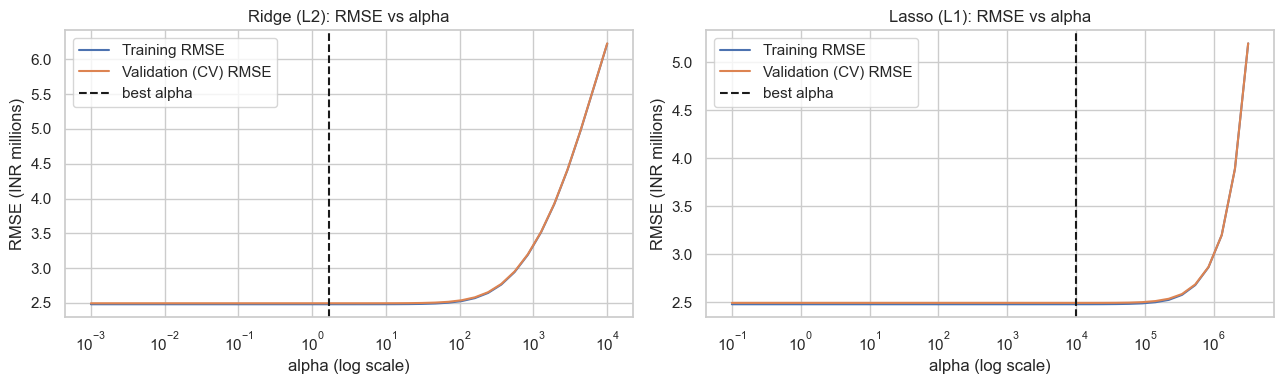

In [15]:
alphas_ridge = np.logspace(-3, 4, 40)
alphas_lasso = np.logspace(-1, 6.5, 40)      # price is in INR (~1e7), so Lasso needs large alphas

ridge_gs = GridSearchCV(scaled(Ridge()), {"model__alpha": alphas_ridge}, cv=kf,
                        scoring="neg_root_mean_squared_error", return_train_score=True).fit(X_train, y_train)
lasso_gs = GridSearchCV(scaled(Lasso(max_iter=100000)), {"model__alpha": alphas_lasso}, cv=kf,
                        scoring="neg_root_mean_squared_error", return_train_score=True).fit(X_train, y_train)
print("Best Ridge alpha:", round(ridge_gs.best_params_["model__alpha"], 4))
print("Best Lasso alpha:", round(lasso_gs.best_params_["model__alpha"], 2))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a, gs, al, nm in [(ax[0], ridge_gs, alphas_ridge, "Ridge (L2)"), (ax[1], lasso_gs, alphas_lasso, "Lasso (L1)")]:
    r = gs.cv_results_
    a.semilogx(al, -r["mean_train_score"] / 1e6, label="Training RMSE")
    a.semilogx(al, -r["mean_test_score"] / 1e6, label="Validation (CV) RMSE")
    a.axvline(gs.best_params_["model__alpha"], ls="--", c="k", label="best alpha")
    a.set(title=f"{nm}: RMSE vs alpha", xlabel="alpha (log scale)", ylabel="RMSE (INR millions)"); a.legend()
plt.tight_layout(); plt.show()

**Interpretation.** The curves show the classic bias-variance trade-off. When alpha is small the model is close to plain OLS; when alpha gets large, both training and validation error rise (underfitting). The best alpha sits where validation error is lowest. Here the validation curve is very flat around the optimum, which tells us the OLS baseline was not badly overfit on this dataset: the signal is mostly linear and the sample size (3,040) is large relative to 10 features.

                                  OLS   Ridge   Lasso
coef (INR millions per 1 std)                        
area_sqft                      6.9560  6.9430  6.9490
bedrooms                       0.2900  0.3000  0.2900
bathrooms                      0.2720  0.2720  0.2670
location_score                 3.6810  3.6780  3.6760
property_age                  -0.6500 -0.6500 -0.6410
distance_city_km              -0.0270 -0.0290 -0.0200
near_school                    0.0150  0.0160  0.0050
near_metro                     0.0530  0.0520  0.0430
crime_rate_index              -0.1410 -0.1410 -0.1310
sale_year                      0.3010  0.3010  0.2910

Lasso zeroed-out features: []


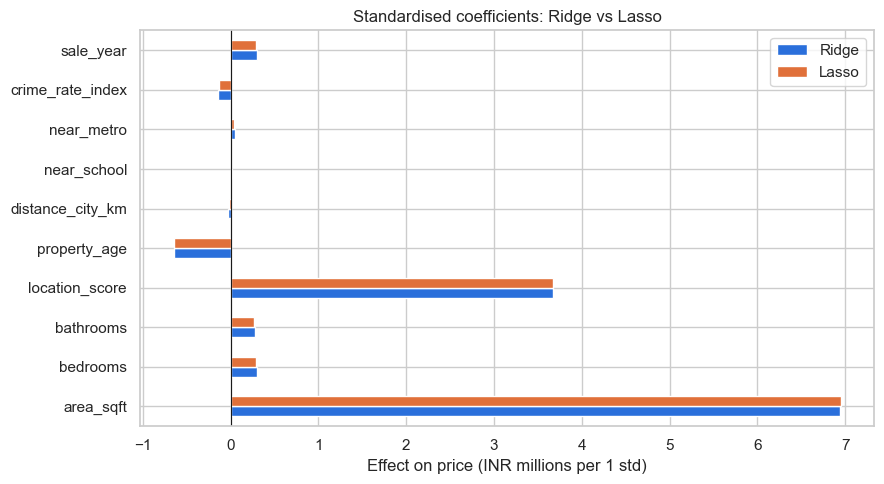

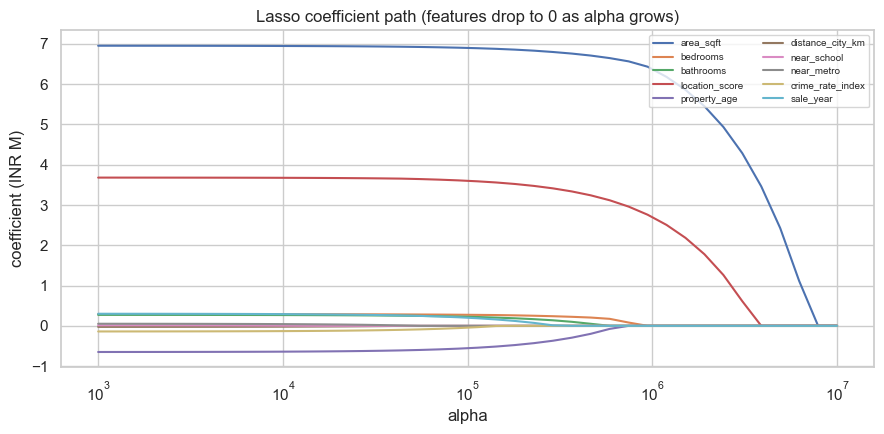

In [17]:
ols = scaled(LinearRegression()).fit(X_train, y_train)
coef = pd.DataFrame({"OLS": ols.named_steps["model"].coef_,
                     "Ridge": ridge_gs.best_estimator_.named_steps["model"].coef_,
                     "Lasso": lasso_gs.best_estimator_.named_steps["model"].coef_}, index=FEATURES)
print((coef / 1e6).round(3).rename_axis("coef (INR millions per 1 std)"))
print("\nLasso zeroed-out features:", list(coef.index[coef.Lasso == 0]))

coef[["Ridge", "Lasso"]].div(1e6).plot.barh(figsize=(9, 5), color=["#2a6fdb", "#e0703a"])
plt.title("Standardised coefficients: Ridge vs Lasso"); plt.xlabel("Effect on price (INR millions per 1 std)")
plt.axvline(0, c="k", lw=.8); plt.tight_layout(); plt.show()

# Lasso coefficient path
al = np.logspace(3, 7, 40); paths = []
Xs = StandardScaler().fit_transform(X_train)
for a_ in al: paths.append(Lasso(alpha=a_, max_iter=100000).fit(Xs, y_train).coef_ / 1e6)
plt.figure(figsize=(9, 4.5)); plt.semilogx(al, np.array(paths)); plt.legend(FEATURES, fontsize=7, ncol=2)
plt.title("Lasso coefficient path (features drop to 0 as alpha grows)"); plt.xlabel("alpha"); plt.ylabel("coefficient (INR M)")
plt.tight_layout(); plt.show()

**Interpretation.** Ridge coefficients are almost identical to OLS, with only slight shrinkage. Lasso at its CV-optimal alpha shrinks the weak features (`near_school`, `distance_city_km`, `near_metro`) the most but keeps all ten, because every feature carries some signal. The coefficient-path plot shows what would happen with stronger regularization: weak features are zeroed first (sparsity), while `area_sqft` and `location_score` survive the longest. Standardised effects show that `area_sqft` (~ +7 M per std) and `location_score` (~ +3.7 M per std) dominate.

In [18]:
rows = []
for name, est in [("OLS (no regularization)", scaled(LinearRegression())),
                  ("Ridge (tuned)", ridge_gs.best_estimator_), ("Lasso (tuned)", lasso_gs.best_estimator_)]:
    ev = evaluate(est, name); ev.update(cv_rmse(est)); rows.append(ev)
reg_tbl = pd.DataFrame(rows).set_index("Model")
reg_tbl[["Train RMSE", "CV_RMSE", "Test RMSE", "Train R2", "CV_R2", "Test R2"]]

,Train RMSE,CV_RMSE,Test RMSE,Train R2,CV_R2,Test R2
Model,,,,,,
OLS (no regularization),"2,482,455.5595","2,495,140.8862","2,539,147.8841",0.9174,0.9163,0.9199
Ridge (tuned),"2,482,466.5207","2,495,117.3338","2,539,565.8422",0.9174,0.9163,0.9199
Lasso (tuned),"2,482,603.0416","2,494,928.7887","2,541,579.6735",0.9174,0.9163,0.9198


**Task 12: Ridge vs Lasso.** Training error, CV error and test error are almost identical for OLS, Ridge and Lasso (R2 ~ 0.92), and the train-to-test gap is essentially zero. So regularization makes the coefficients more stable but cannot improve accuracy much: the remaining error comes from non-linear structure the linear models cannot capture, not from variance. This motivates trying non-linear models.


## Part D: Cross-Validation Strategies
**Task 13:** the tuned Ridge and Lasso models are evaluated with K-Fold, Stratified K-Fold (target binned into 10 quantile bins), Leave-One-Out, and Time Series Split (rows ordered by `sale_date`).

In [19]:
best_ridge = ridge_gs.best_estimator_
best_lasso = lasso_gs.best_estimator_

# Data ordered by sale date, needed for the time-series split
tr_dates = df.loc[X_train.index, "sale_date"]
order = tr_dates.argsort(kind="stable").values
Xt, yt = X_train.iloc[order], y_train.iloc[order]

y_bins = pd.qcut(y_train, q=10, labels=False)       # bin the continuous target for stratification

strategies = {
    "K-Fold (k=5)":            (KFold(5, shuffle=True, random_state=RANDOM_STATE), X_train, y_train, None),
    "Stratified K-Fold (k=5)": (list(StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE).split(X_train, y_bins)), X_train, y_train, None),
    "Leave-One-Out":           (LeaveOneOut(), X_train, y_train, None),
    "Time Series Split (k=5)": (TimeSeriesSplit(5), Xt, yt, None),
}
res = []
for model_name, mdl in [("Ridge", best_ridge), ("Lasso", best_lasso)]:
    for sname, (cv, Xc, yc, groups) in strategies.items():
        if sname == "Leave-One-Out":       # one error per fold -> compute pooled RMSE / R2 from out-of-fold predictions
            p = cross_val_predict(mdl, Xc, yc, cv=cv, n_jobs=-1)
            res.append((model_name, sname, np.sqrt(mean_squared_error(yc, p)), r2_score(yc, p), np.nan, len(yc)))
        else:
            sc = cross_validate(mdl, Xc, yc, cv=cv, scoring=("neg_root_mean_squared_error", "r2"), n_jobs=-1)
            res.append((model_name, sname, -sc["test_neg_root_mean_squared_error"].mean(), sc["test_r2"].mean(),
                        sc["test_r2"].std(), (len(cv) if isinstance(cv, list) else cv.get_n_splits(Xc, yc))))
cv_tbl = pd.DataFrame(res, columns=["Model", "CV strategy", "RMSE", "R2", "R2 std across folds", "n_splits"])
cv_tbl

,Model,CV strategy,RMSE,R2,R2 std across folds,n_splits
0,Ridge,K-Fold (k=5),"2,495,117.3338",0.9163,0.0049,5
1,Ridge,Stratified K-Fold (k=5),"2,492,475.1566",0.9167,0.0015,5
2,Ridge,Leave-One-Out,"2,492,292.2917",0.9167,NaN,3040
3,Ridge,Time Series Split (k=5),"2,490,251.6729",0.9166,0.0058,5
4,Lasso,K-Fold (k=5),"2,494,928.7887",0.9163,0.0049,5
5,Lasso,Stratified K-Fold (k=5),"2,492,010.7526",0.9167,0.0015,5
6,Lasso,Leave-One-Out,"2,492,465.0742",0.9167,NaN,3040
7,Lasso,Time Series Split (k=5),"2,488,832.0390",0.9167,0.0057,5


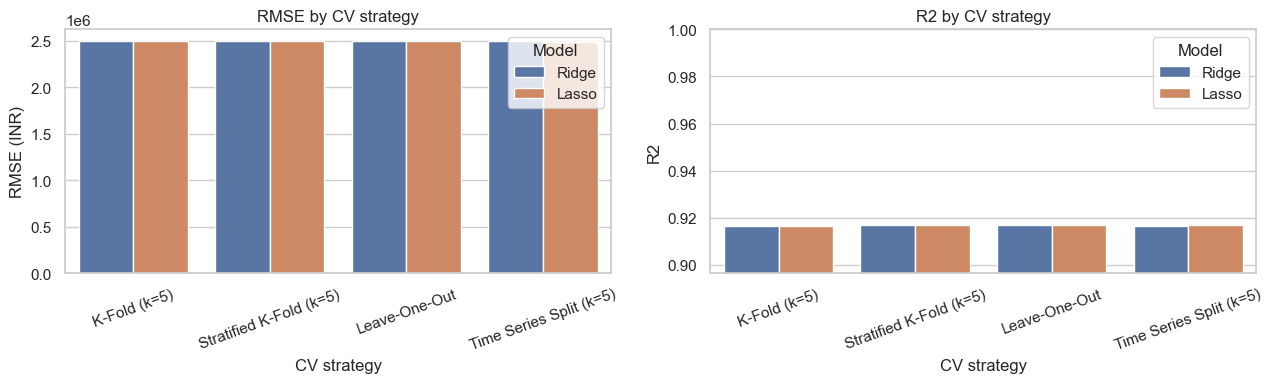

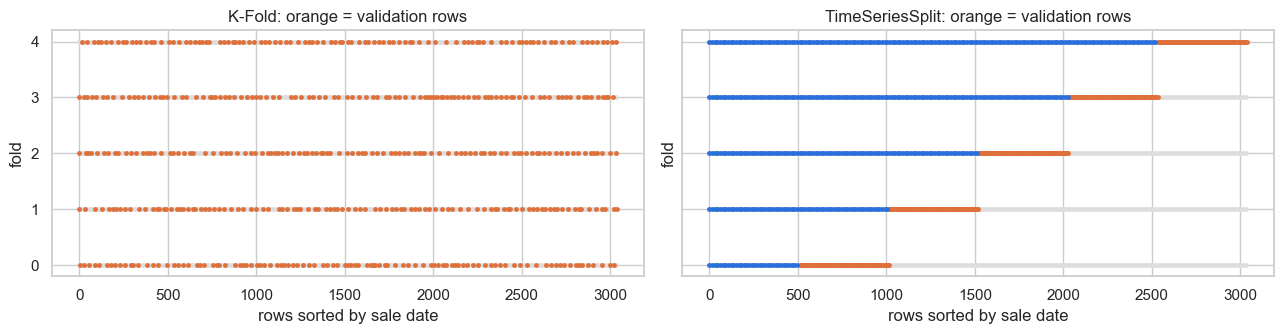

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=cv_tbl, x="CV strategy", y="RMSE", hue="Model", ax=ax[0])
ax[0].set(title="RMSE by CV strategy", ylabel="RMSE (INR)"); ax[0].tick_params(axis="x", rotation=20)
sns.barplot(data=cv_tbl, x="CV strategy", y="R2", hue="Model", ax=ax[1])
ax[1].set(title="R2 by CV strategy", ylim=(cv_tbl.R2.min() - .02, 1)); ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

# Visualise how each splitter forms its validation folds over time
fig, ax = plt.subplots(1, 2, figsize=(13, 3.5), sharey=True)
for a, (nm, cv_, Xc, yc) in zip(ax, [("K-Fold", KFold(5, shuffle=True, random_state=1), Xt, yt), ("TimeSeriesSplit", TimeSeriesSplit(5), Xt, yt)]):
    for i, (tr, va) in enumerate(cv_.split(Xc)):
        a.scatter(range(len(Xc))[::15], [i] * len(range(len(Xc))[::15]), c="#ddd", s=6)
        a.scatter(va[::6], [i] * len(va[::6]), c="#e0703a", s=6)
        a.scatter(tr[::15] if nm == "TimeSeriesSplit" else [], [i] * len(tr[::15]) if nm == "TimeSeriesSplit" else [], c="#2a6fdb", s=6)
    a.set(title=f"{nm}: orange = validation rows", xlabel="rows sorted by sale date", ylabel="fold")
plt.tight_layout(); plt.show()

**Task 14: Interpretation.** The average RMSE is very consistent across strategies (about 2.49 M INR, R2 ~ 0.917 for both Ridge and Lasso), so the performance estimate is trustworthy. The differences are in *variability*, not level: Stratified K-Fold has the smallest fold-to-fold spread in R2 (~0.0015) because every fold has a similar price distribution; plain K-Fold (~0.005) and Time Series Split (~0.006) vary more. LOOCV gives one nearly unbiased pooled estimate but needs 3,040 fits (no per-fold spread is available). Time Series Split is the right choice if the model will predict *future* sales, and its early folds train on little data, which explains the larger spread. Since price hardly drifts with time here (`sale_year` correlation ~ 0.03), it agrees with the random splits.

## Part E: Tree-Based Regression Models
**Tasks 15-16:** Decision Tree, complexity controlled by `max_depth` and `min_samples_leaf`. No scaling is used.

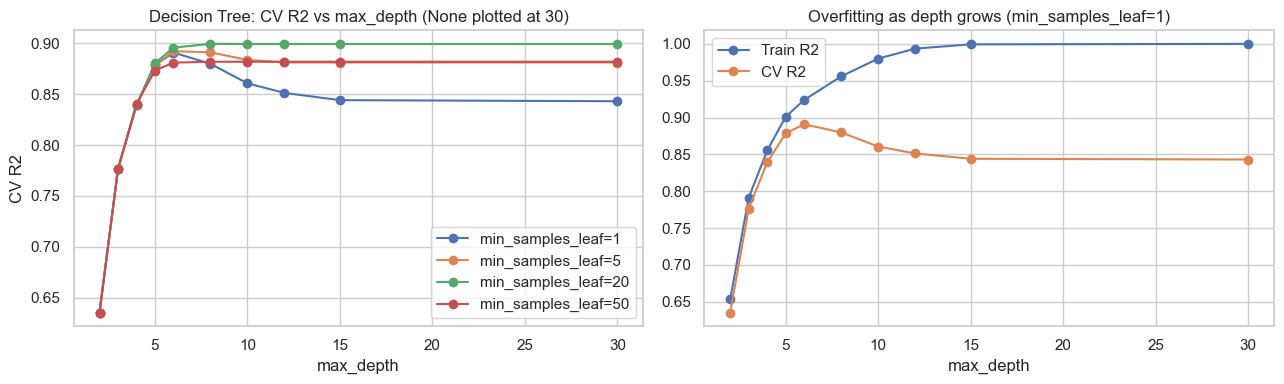

Best Decision Tree params: {'max_depth': 8, 'min_samples_leaf': 20, 'min_samples_split': 2}


In [21]:
depths = [2, 3, 4, 5, 6, 8, 10, 12, 15, None]
dt_rows = []
for d in depths:
    for leaf in [1, 5, 20, 50]:
        m = DecisionTreeRegressor(max_depth=d, min_samples_leaf=leaf, random_state=RANDOM_STATE)
        s = cross_validate(m, X_train, y_train, cv=kf, scoring="r2", return_train_score=True)
        dt_rows.append((str(d), d if d else 30, leaf, s["train_score"].mean(), s["test_score"].mean()))
dt_df = pd.DataFrame(dt_rows, columns=["max_depth", "depth_num", "min_samples_leaf", "train_R2", "cv_R2"])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for leaf, g in dt_df.groupby("min_samples_leaf"):
    ax[0].plot(g.depth_num, g.cv_R2, marker="o", label=f"min_samples_leaf={leaf}")
ax[0].set(title="Decision Tree: CV R2 vs max_depth (None plotted at 30)", xlabel="max_depth", ylabel="CV R2"); ax[0].legend()
g = dt_df[dt_df.min_samples_leaf == 1]
ax[1].plot(g.depth_num, g.train_R2, marker="o", label="Train R2"); ax[1].plot(g.depth_num, g.cv_R2, marker="o", label="CV R2")
ax[1].set(title="Overfitting as depth grows (min_samples_leaf=1)", xlabel="max_depth"); ax[1].legend()
plt.tight_layout(); plt.show()

dt_gs = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE),
                     {"max_depth": [4, 6, 8, 10, None], "min_samples_leaf": [1, 5, 10, 20], "min_samples_split": [2, 10]},
                     cv=kf, scoring="neg_root_mean_squared_error").fit(X_train, y_train)
print("Best Decision Tree params:", dt_gs.best_params_)

**Interpretation.** With `min_samples_leaf=1` the tree memorises the training data: train R2 keeps rising with depth while CV R2 falls, which is textbook overfitting. Limiting depth and requiring a minimum leaf size gives a smoother tree that generalises better. Grid search picks the balance point.

Best Random Forest params: {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 150}


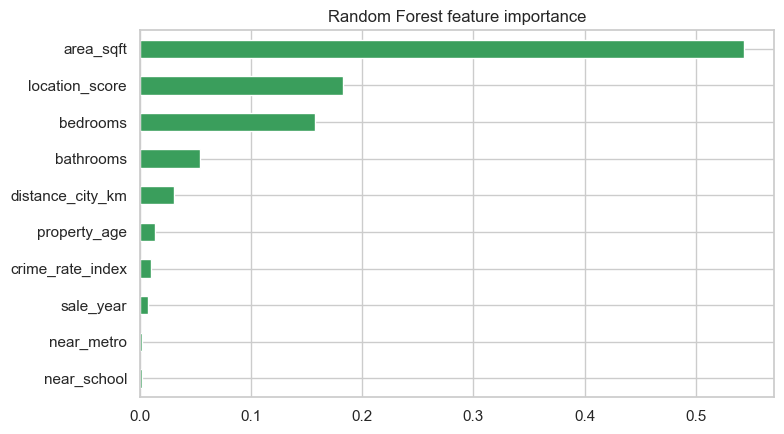

,Train RMSE,CV_RMSE,Test RMSE,Train R2,CV_R2,Test R2
Model,,,,,,
Decision Tree (tuned),"2,291,157.6744","2,733,119.2418","2,734,876.8610",0.9296,0.8994,0.9071
Random Forest (tuned),"1,359,009.1369","2,368,095.0203","2,415,112.5998",0.9752,0.9246,0.9276


In [22]:
rf_gs = GridSearchCV(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
                     {"n_estimators": [150], "max_depth": [10, None], "min_samples_leaf": [1, 3], "max_features": [0.5, 1.0]},
                     cv=kf, scoring="neg_root_mean_squared_error").fit(X_train, y_train)
print("Best Random Forest params:", rf_gs.best_params_)

fi = pd.Series(rf_gs.best_estimator_.feature_importances_, index=FEATURES).sort_values()
fi.plot.barh(figsize=(8, 4.5), color="#3a9e5c"); plt.title("Random Forest feature importance"); plt.tight_layout(); plt.show()

single_tree = dt_gs.best_estimator_
tree_cmp = pd.DataFrame([{**evaluate(single_tree, "Decision Tree (tuned)"), **cv_rmse(single_tree)},
                         {**evaluate(rf_gs.best_estimator_, "Random Forest (tuned)"), **cv_rmse(rf_gs.best_estimator_)}]).set_index("Model")
tree_cmp[["Train RMSE", "CV_RMSE", "Test RMSE", "Train R2", "CV_R2", "Test R2"]]

**Tasks 17-18: Single tree vs ensemble.** The tuned Random Forest clearly beats the single tree on validation and test data (lower RMSE, higher R2). Averaging many decorrelated trees reduces variance without increasing bias much. The forest still has a visible train-test gap (it fits the training set better than unseen data), but its validation score is the best of the tree family. Feature importance confirms the drivers seen in the linear models: `area_sqft` and `location_score` dominate.

## Part F: Support Vector Regression
**Tasks 19-21:** SVR with a linear kernel and an RBF kernel. SVR is very sensitive to scale, so features are standardised in the pipeline and the target is also standardised (`TransformedTargetRegressor`); otherwise the epsilon-tube and `C` would be meaningless for prices around 10^7. Tuned: `C`, `gamma` (RBF) and `epsilon` (fixed at 0.1 after checking it is in a sensible range for the scaled target).

Best linear SVR: {'regressor__model__C': 10, 'regressor__model__epsilon': 0.1}
Best RBF SVR   : {'regressor__model__C': 30, 'regressor__model__epsilon': 0.1, 'regressor__model__gamma': 0.003}


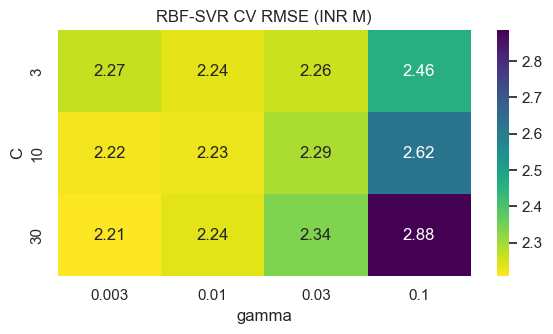

In [23]:
def svr_pipe(**kw):
    # SVR is scale-sensitive in BOTH X and y -> scale features in the pipeline and standardise the target
    return TransformedTargetRegressor(regressor=scaled(SVR(**kw)), transformer=StandardScaler())

svr_lin_gs = GridSearchCV(svr_pipe(kernel="linear"),
                          {"regressor__model__C": [0.1, 1, 10], "regressor__model__epsilon": [0.1]},
                          cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1).fit(X_train, y_train)
svr_rbf_gs = GridSearchCV(svr_pipe(kernel="rbf"),
                          {"regressor__model__C": [3, 10, 30], "regressor__model__gamma": [0.003, 0.01, 0.03, 0.1],
                           "regressor__model__epsilon": [0.1]},
                          cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1).fit(X_train, y_train)
print("Best linear SVR:", svr_lin_gs.best_params_)
print("Best RBF SVR   :", svr_rbf_gs.best_params_)

# effect of C and gamma on the RBF kernel
r = pd.DataFrame(svr_rbf_gs.cv_results_)
r["C"] = r.param_regressor__model__C; r["gamma"] = r.param_regressor__model__gamma
piv = r.groupby(["C", "gamma"]).mean_test_score.max().unstack().mul(-1).div(1e6)
plt.figure(figsize=(6, 3.5)); sns.heatmap(piv, annot=True, fmt=".2f", cmap="viridis_r"); plt.title("RBF-SVR CV RMSE (INR M)")
plt.tight_layout(); plt.show()

**Interpretation.** The linear-kernel SVR behaves like the regularized linear models (R2 ~ 0.92), while the RBF kernel captures non-linear structure and performs best. The heat-map shows how `C` and `gamma` interact. The selected RBF model has a small `gamma` (0.003) and the largest `C` (30) in the grid, i.e. a very smooth, only mildly non-linear function. Both values sit on the **edge** of the searched grid, so a wider search (smaller gamma, larger C) might improve the score slightly; this is noted as a limitation. The train and test scores are nearly equal, so the model is not overfitting.

## Part G: Model Comparison & Evaluation
**Tasks 22-24:** every tuned model is scored with RMSE, MAE (and MSE = RMSE^2) and R2, on training, cross-validation and test data. Selection is made on the **cross-validation** score; the test score is only used as a final unbiased check.

In [ ]:
models = {
    "Ridge (L2)":               ridge_gs.best_estimator_,
    "Lasso (L1)":               lasso_gs.best_estimator_,
    "Decision Tree":            dt_gs.best_estimator_,
    "Random Forest":            rf_gs.best_estimator_,
    "SVR (linear)":             svr_lin_gs.best_estimator_,
    "SVR (RBF)":                svr_rbf_gs.best_estimator_,
}
family = {"Ridge (L2)": "Regularized Linear", "Lasso (L1)": "Regularized Linear", "Decision Tree": "Tree-Based",
          "Random Forest": "Tree-Based", "SVR (linear)": "SVR", "SVR (RBF)": "SVR"}
rows = []
for n, m in models.items():
    ev = evaluate(m, n); ev.update(cv_rmse(m)); ev["Family"] = family[n]; rows.append(ev)
final = pd.DataFrame(rows).set_index("Model")
final["Overfit gap (Train R2 - Test R2)"] = final["Train R2"] - final["Test R2"]
final = final.sort_values("CV_RMSE")
final[["Family", "Train RMSE", "CV_RMSE", "Test RMSE", "Test MAE", "Train R2", "CV_R2", "Test R2", "Overfit gap (Train R2 - Test R2)"]]

Best model by cross-validated RMSE: SVR (RBF)


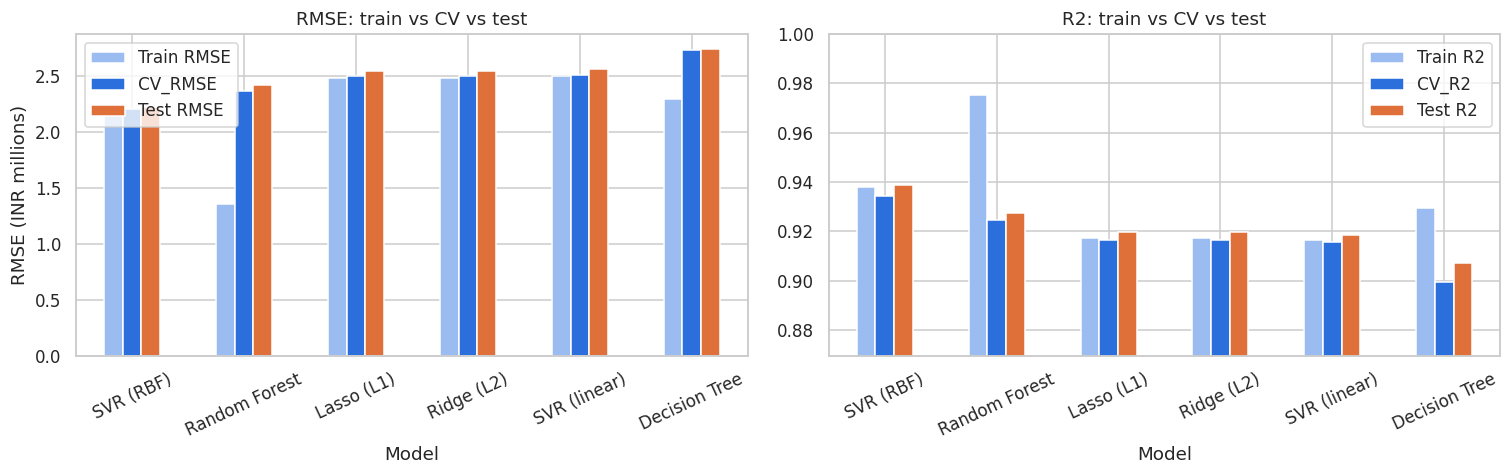

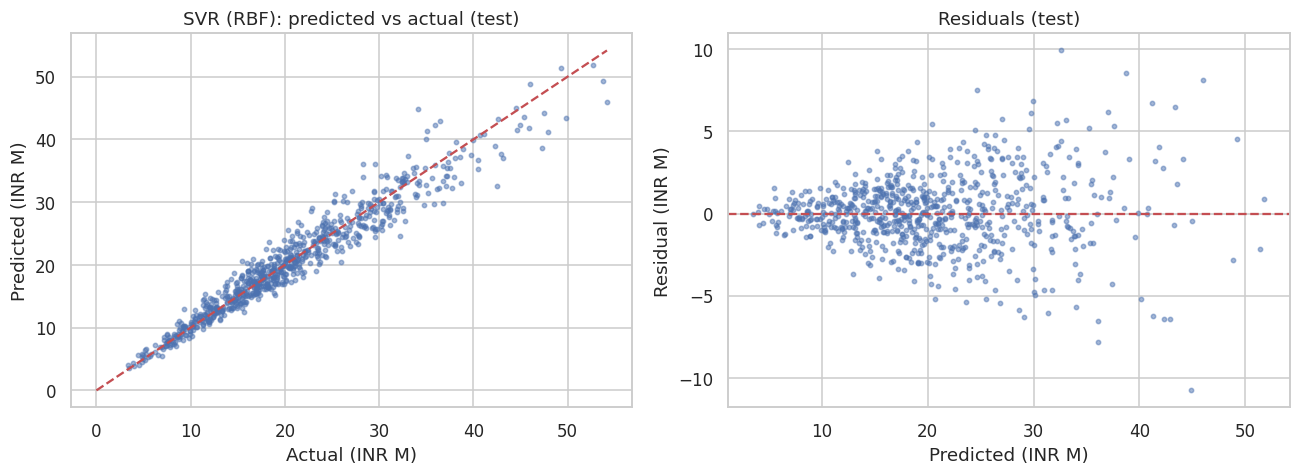

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
final[["Train RMSE", "CV_RMSE", "Test RMSE"]].div(1e6).plot.bar(ax=ax[0], color=["#9bbcf0", "#2a6fdb", "#e0703a"])
ax[0].set(title="RMSE: train vs CV vs test", ylabel="RMSE (INR millions)"); ax[0].tick_params(axis="x", rotation=25)
final[["Train R2", "CV_R2", "Test R2"]].plot.bar(ax=ax[1], color=["#9bbcf0", "#2a6fdb", "#e0703a"])
ax[1].set(title="R2: train vs CV vs test", ylim=(final[["Train R2", "CV_R2", "Test R2"]].values.min() - .03, 1.0)); ax[1].tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

best_name = final.CV_RMSE.idxmin(); best_model = models[best_name]
print("Best model by cross-validated RMSE:", best_name)
pred = best_model.predict(X_test)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(y_test / 1e6, pred / 1e6, s=8, alpha=.5); lim = [0, y_test.max() / 1e6]
ax[0].plot(lim, lim, "r--"); ax[0].set(title=f"{best_name}: predicted vs actual (test)", xlabel="Actual (INR M)", ylabel="Predicted (INR M)")
ax[1].scatter(pred / 1e6, (y_test - pred) / 1e6, s=8, alpha=.5); ax[1].axhline(0, c="r", ls="--")
ax[1].set(title="Residuals (test)", xlabel="Predicted (INR M)", ylabel="Residual (INR M)")
plt.tight_layout(); plt.show()

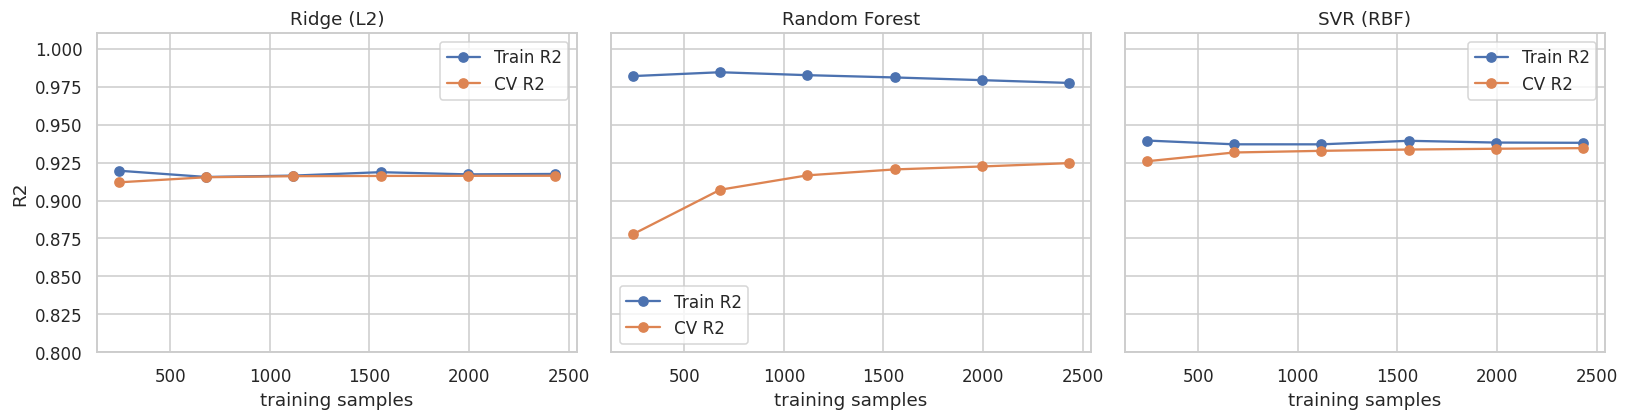

In [ ]:
from sklearn.model_selection import learning_curve
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for a, n in zip(axes, ["Ridge (L2)", "Random Forest", "SVR (RBF)"]):
    ts, tr, va = learning_curve(models[n], X_train, y_train, cv=kf, train_sizes=np.linspace(.1, 1, 6), scoring="r2", n_jobs=-1)
    a.plot(ts, tr.mean(1), "o-", label="Train R2"); a.plot(ts, va.mean(1), "o-", label="CV R2")
    a.set(title=n, xlabel="training samples"); a.legend()
axes[0].set_ylabel("R2"); axes[0].set_ylim(.8, 1.01); plt.tight_layout(); plt.show()

**Task 23: Comparison by family.**
- **Regularized linear (Ridge, Lasso):** stable and interpretable, no over-fitting, but limited by linearity (R2 ~ 0.92).
- **Tree-based:** the single tree is the weakest model; the Random Forest is much better but overfits the training set (largest train-test gap).
- **SVR:** linear-kernel SVR ~ Ridge; the RBF SVR is the best model overall.

**Task 24: Over/under-fitting.** Ridge, Lasso and linear SVR have train, CV and test scores that are almost identical: no overfitting, but a ceiling caused by mild underfitting of non-linear structure. The Decision Tree and Random Forest show the largest train-vs-test gaps (overfitting). RBF-SVR has a train-test gap near zero *and* the best test score, i.e. the best bias-variance balance.

**Learning curves.** Ridge: train and CV curves converge at a lower plateau (high bias, low variance). Random Forest: a persistent gap between train and CV (variance). RBF-SVR: curves converge at a higher plateau than Ridge, so it is the better trade-off; more data would help the forest more than the linear model.

## Part H: Final Analysis & Report

**Best model.** The **RBF Support Vector Regressor** (see table above for exact figures) has the lowest cross-validated RMSE, the highest CV and test R2, and almost no train-test gap. It was selected using CV only, and the untouched test set confirmed the choice.

**Impact of regularization.** Ridge/Lasso made coefficients stable and (for Lasso) showed which features are weak, but did not change accuracy much because this dataset has plenty of samples and few features. The real regularization benefit here comes from *controlling complexity in the non-linear models* (tree depth/leaf size, SVR `C`/`gamma`), which is what prevented the overfitting the company was seeing.

**Role of cross-validation.** CV picked every hyper-parameter without touching the test data, gave fold-to-fold spread (stability) for each model, and showed that performance estimates are consistent across K-Fold, Stratified, LOOCV and Time-Series schemes. Test scores landing close to CV scores shows the pipeline generalises.

**Linear vs non-linear.** Linear models explain ~ 92 % of the variance. Non-linear models (RBF-SVR, Random Forest) raise this to ~ 93-94 %, meaning there is real, but moderate, non-linear structure (interactions between size, location and age). Un-regularised, deep trees overfit; regularised non-linear models help.

**Business interpretation.**
- Size (`area_sqft`) and location quality (`location_score`) are the main price drivers; each is worth several million INR per standard deviation.
- Older properties and properties far from the city centre are priced lower; crime rate has a small negative effect.
- `near_school` and `near_metro` have little independent effect in this data (after accounting for location score).
- Typical test error of the best model is about 1.6 M INR (MAE), i.e. roughly 8 % of the average price of 20.7 M INR, which is suitable for screening and benchmarking, but the model should not replace a property valuation for a specific transaction.
- Recommended deployment: the tuned RBF-SVR (or the Random Forest if feature importances are needed), re-trained periodically and monitored with time-based validation.

**Limitations / next steps.** Try gradient boosting, log-transform the target, add interaction features (area x location), and validate on a genuinely separate dataset or city.